# [Dynamic Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html)

Dynamic topic modeling (DTM) is a collection of techniques aimed at analyzing the evolution of topics over time. These methods allow you to understand how a topic is represented across different times. For example, in 1995 people may talk differently about environmental awareness than those in 2015. Although the topic itself remains the same, environmental awareness, the exact representation of that topic might differ.

BERTopic allows for DTM by calculating the topic representation at each timestep without the need to run the entire model several times. To do this, we first need to fit BERTopic as if there were no temporal aspect in the data. Thus, a general topic model will be created. We use the global representation as to the main topics that can be found at, most likely, different timesteps. For each topic and timestep, we calculate the c-TF-IDF representation. This will result in a specific topic representation at each timestep without the need to create clusters from embeddings as they were already created.

Next, there are two main ways to further fine-tune these specific topic representations, namely globally and evolutionary.

A topic representation at timestep t can be fine-tuned globally by averaging its c-TF-IDF representation with that of the global representation. This allows each topic representation to move slightly towards the global representation whilst still keeping some of its specific words.

A topic representation at timestep t can be fine-tuned evolutionary by averaging its c-TF-IDF representation with that of the c-TF-IDF representation at timestep t-1. This is done for each topic representation allowing for the representations to evolve over time.

Both fine-tuning methods are set to True as a default and allow for interesting representations to be created.

## Example

To demonstrate DTM in BERTopic, we first need to prepare our data. A good example of where DTM is useful is topic modeling on Twitter data. We can analyze how certain people have talked about certain topics in the years they have been on Twitter. Due to the controversial nature of his tweets, we are going to be using all tweets by Donald Trump.

First, we need to load the data and do some very basic cleaning. For example, I am not interested in his re-tweets for this use-case:

In [1]:
import re
import pandas as pd

# Prepare data
trump = pd.read_csv('https://drive.google.com/uc?export=download&id=1xRKHaP-QwACMydlDnyFPEaFdtskJuBa6')
trump.text = trump.apply(lambda row: re.sub(r"http\S+", "", row.text).lower(), 1)
trump.text = trump.apply(lambda row: " ".join(filter(lambda x:x[0]!="@", row.text.split())), 1)
trump.text = trump.apply(lambda row: " ".join(re.sub("[^a-zA-Z]+", " ", row.text).split()), 1)
trump = trump.loc[(trump.isRetweet == "f") & (trump.text != ""), :]
timestamps = trump.date.to_list()
tweets = trump.text.to_list()

Then, we need to extract the global topic representations by simply creating and training a BERTopic model:

In [2]:
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(tweets)

2025-03-12 15:14:08,453 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1418 [00:00<?, ?it/s]

2025-03-12 15:14:36,173 - BERTopic - Embedding - Completed ✓
2025-03-12 15:14:36,173 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-03-12 15:14:54,292 - BERTopic - Dimensionality - Completed ✓
2025-03-12 15:14:54,294 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the

From these topics, we are going to generate the topic representations at each timestamp for each topic. We do this by simply calling topics_over_time and passing the tweets, the corresponding timestamps, and the related topics:

In [3]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)

20it [00:07,  2.69it/s]


In [4]:
topics_over_time

,Topic,Words,Frequency,Timestamp
0,-1,"keychain, donald, contest, stuf, achiever",17,2009-04-30 12:30:07.597
1,0,"execute, imagination, direct, utilize, precipice",9,2009-04-30 12:30:07.597
2,3,"begun, schedule, ahead, international, scotland",1,2009-04-30 12:30:07.597
3,7,"apprentice, randal, pinkett, lieutenant, celeb...",3,2009-04-30 12:30:07.597
4,18,"ivanka, gma, jared, entrepreneurial, sharing",4,2009-04-30 12:30:07.597
...,...,...,...,...
4223,541,"rush, greatest, limbaugh, guy, is",1,2020-06-09 07:29:57.850
4224,542,"campaign, enthusiasm, spirit, books, written",1,2020-06-09 07:29:57.850
4225,546,"herschel, truth, speaking, dianemarshall, ukca...",1,2020-06-09 07:29:57.850
4226,547,"john, such, honor, thank, johndoe",1,2020-06-09 07:29:57.850


And that is it! Aside from what you always need for BERTopic, you now only need to add timestamps to quickly calculate the topics over time

## Parameters
There are a few parameters that are of interest which will be discussed below.

### Tuning
Both global_tuning and evolutionary_tuning are set to True as a default, but can easily be changed. Perhaps you do not want the representations to be influenced by the global representation and merely see how they evolved over time:

In [4]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, 
                                                global_tuning=True, evolution_tuning=True, nr_bins=20)

20it [00:07,  2.64it/s]


### Bins

If you have more than 100 unique timestamps, then there will be topic representations created for each of those timestamps which can negatively affect the topic representations. It is advised to keep the number of unique timestamps below 50. To do this, you can simply set the number of bins that are created when calculating the topic representations. The timestamps will be taken and put into equal-sized bins:

In [5]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)

20it [00:07,  2.66it/s]


### Datetime format

If you are passing strings (dates) instead of integers, then BERTopic will try to automatically detect which datetime format your strings have. Unfortunately, this will not always work if they are in an unexpected format. We can use datetime_format to pass the format the timestamps have:

In [8]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, datetime_format="%Y-%m-%d %H:%M:%S", nr_bins=20)

20it [00:07,  2.69it/s]


## Visualization

To me, DTM becomes truly interesting when you have a good way of visualizing how topics have changed over time. A nice way of doing so is by leveraging the interactive abilities of Plotly. Plotly allows us to show the frequency of topics over time whilst giving the option of hovering over the points to show the time-specific topic representations. Simply call visualize_topics_over_time with the newly created topics over time:

In [9]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

I used top_n_topics to only show the top 20 most frequent topics. If I were to visualize all topics, which is possible by leaving top_n_topics empty, there is a chance that hundreds of lines will fill the plot.

You can also use topics to show specific topics:


In [10]:
topic_model.visualize_topics_over_time(topics_over_time, topics=[9, 10, 72, 83, 87, 91])


# [Hierarchical Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/hierarchicaltopics/hierarchicaltopics.html#visualizations)

When tweaking your topic model, the number of topics that are generated has a large effect on the quality of the topic representations. Some topics could be merged and having an understanding of the effect will help you understand which topics should and which should not be merged.

That is where hierarchical topic modeling comes in. It tries to model the possible hierarchical nature of the topics you have created to understand which topics are similar to each other. Moreover, you will have more insight into sub-topics that might exist in your data.

In BERTopic, we can approximate this potential hierarchy by making use of our topic-term matrix (c-TF-IDF matrix). This matrix contains information about the importance of every word in every topic and makes for a nice numerical representation of our topics. The smaller the distance between two c-TF-IDF representations, the more similar we assume they are. In practice, this process of merging topics is done through the hierarchical clustering capabilities of scipy (see here). It allows for several linkage methods through which we can approximate our topic hierarchy. As a default, we are using the ward but many others are available.

Whenever we merge two topics, we can calculate the c-TF-IDF representation of these two merged by summing their bag-of-words representation. We assume that two sets of topics are merged and that all others are kept the same, regardless of their location in the hierarchy. This helps us isolate the potential effect of merging sets of topics. As a result, we can see the topic representation at each level in the tree.

## Example

To demonstrate hierarchical topic modeling with BERTopic, we use the 20 Newsgroups dataset to see how the topics that we uncover are represented in the 20 categories of documents.

First, we train a basic BERTopic model:




In [11]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))["data"]
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(docs)


2025-03-12 16:45:31,143 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-03-12 16:46:33,864 - BERTopic - Embedding - Completed ✓
2025-03-12 16:46:33,865 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-12 16:46:37,646 - BERTopic - Dimensionality - Completed ✓
2025-03-12 16:46:37,648 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current p

Next, we can use our fitted BERTopic model to extract possible hierarchies from our c-TF-IDF matrix:

In [12]:
hierarchical_topics = topic_model.hierarchical_topics(docs)

100%|██████████| 216/216 [00:00<00:00, 398.66it/s]


The resulting hierarchical_topics is a dataframe in which merged topics are described. For example, if you would merge two topics, what would the topic representation of the new topic be?

## Linkage functions

When creating the potential hierarchical nature of topics, we use Scipy's ward linkage function as a default to generate the hierarchy. However, you might want to use a different linkage function for your use case, such as single, complete, average, centroid, or median. In BERTopic, you can define the linkage function yourself, including the distance function that you would like to use:




In [13]:
from scipy.cluster import hierarchy as sch
from bertopic import BERTopic
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

# Hierarchical topics
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(docs, linkage_function=linkage_function)


100%|██████████| 212/212 [00:01<00:00, 176.59it/s]


## Visualizations

To visualize these results, we can start by running a familiar function, namely topic_model.visualize_hierarchy:

In [14]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

If you hover over the black circles, you will see the topic representation at that level of the hierarchy. These representations help you understand the effect of merging certain topics. Some might be logical to merge whilst others might not. Moreover, we can now see which sub-topics can be found within certain larger themes.

Although this gives a nice overview of the potential hierarchy, hovering over all black circles can be tiresome. Instead, we can use topic_model.get_topic_tree to create a text-based representation of this hierarchy. Although the general structure is more difficult to view, we can see better which topics could be logically merged:



In [15]:
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─■──maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_mg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9v_14_m4_mp ── Topic: 111
└─the_to_of_and_that
     ├─the_to_of_and_that
     │    ├─■──test_polysyllabic_woof_tuna_uckers ── Topic: 77
     │    └─the_to_of_and_that
     │         ├─the_to_of_and_that
     │         │    ├─the_to_of_and_that
     │         │    │    ├─■──needles_acupuncture_needle_syringe_hypodermic ── Topic: 188
     │         │    │    └─the_to_of_and_that
     │         │    │         ├─■──room_bedroom_kitchen_summer_washer ── Topic: 117
     │         │    │         └─the_to_of_and_that
     │         │    │              ├─the_to_of_and_that
     │         │    │              │    ├─■──deleted_stuff_hurts_deletion_followups ── Topic: 90
     │         │    │              │    └─the_to_of_and_that
     │         │    │              │         ├─the_to_of_and_that
     │         │    │              │         │    ├─■──kirlian_photography_leaf_pictures_krillean ── Topic: 95
     │     

## Merge topics

After seeing the potential hierarchy of your topic, you might want to merge specific topics. For example, if topic 1 is 1_space_launch_moon_nasa and topic 2 is 2_spacecraft_solar_space_orbit it might make sense to merge those two topics as they are quite similar in meaning. In BERTopic, you can use .merge_topics to manually select and merge those topics. Doing so will update their topic representation which in turn updates the entire model:

In [16]:
topics_to_merge = [1, 2]
topic_model.merge_topics(docs, topics_to_merge)

If you have several groups of topics you want to merge, create a list of lists instead:

In [17]:
topics_to_merge = [[1, 2],
                   [3, 4]]
topic_model.merge_topics(docs, topics_to_merge)


# [Multimodal Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/multimodal/multimodal.html)

Documents or text are often accompanied by imagery or the other way around. For example, social media images with captions and products with descriptions. Topic modeling has traditionally focused on creating topics from textual representations. However, as more multimodal representations are created, the need for multimodal topics increases.

BERTopic can perform multimodal topic modeling in a number of ways during .fit and .fit_transform stages.

## Text + Images
The most basic example of multimodal topic modeling in BERTopic is when you have images that accompany your documents. This means that it is expected that each document has an image and vice versa. Instagram pictures, for example, almost always have some descriptions to them.

In this example, we are going to use images from flickr that each have a caption associated to it:

In [18]:
# NOTE: This requires the `datasets` package which you can 
# install with `pip install datasets`
from datasets import load_dataset

ds = load_dataset("maderix/flickr_bw_rgb")
images = ds["train"]["image"]
docs = ds["train"]["caption"]

README.md:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

(…)-00000-of-00001-1686932800440418.parquet:   0%|          | 0.00/335M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7216 [00:00<?, ? examples/s]

The docs variable contains the captions for each image in images. We can now use these variables to run our multimodal example:

In [25]:
from bertopic import BERTopic
from bertopic.representation import VisualRepresentation

# Additional ways of representing a topic
visual_model = VisualRepresentation()

# Make sure to add the `visual_model` to a dictionary
representation_model = {
   "Visual_Aspect":  visual_model,
}
topic_model = BERTopic(representation_model=representation_model, verbose=True)

topics, probs = topic_model.fit_transform(docs, images=images)

2025-03-12 17:45:05,045 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/226 [00:00<?, ?it/s]

2025-03-12 17:45:11,036 - BERTopic - Embedding - Completed ✓
2025-03-12 17:45:11,037 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-12 17:45:13,653 - BERTopic - Dimensionality - Completed ✓
2025-03-12 17:45:13,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-12 17:45:13,775 - BERTopic - Cluster - Completed ✓
2025-03-12 17:45:13,778 - BERTopic - Representation - Extracting topics from clusters using representation models.
100%|██████████| 135/135 [00:04<00:00, 32.30it/s]
2025-03-12 17:45:18,172 - BERTopic - Representation - Completed ✓


In this example, we are clustering the documents and are then looking for the best matching images to the resulting clusters.

We can now access our image representations for each topic with topic_model.topic_aspects_["Visual_Aspect"]. If you want an overview of the topic images together with their textual representations in jupyter, you can run the following:


,Topic,Count,Representation,Visual_Aspect
0,-1,2074,"[of, photograph, and, black, the, white, colorized, on, is, in]",
1,0,215,"[skateboarder, skateboard, skateboarding, trick, ramp, doing, skater, tricks, does, skate]",
2,1,211,"[woman, her, lady, skirt, wearing, with, front, hair, shirt, hand]",
3,2,111,"[girl, dress, pink, young, her, little, flowers, hat, wearing, hair]",

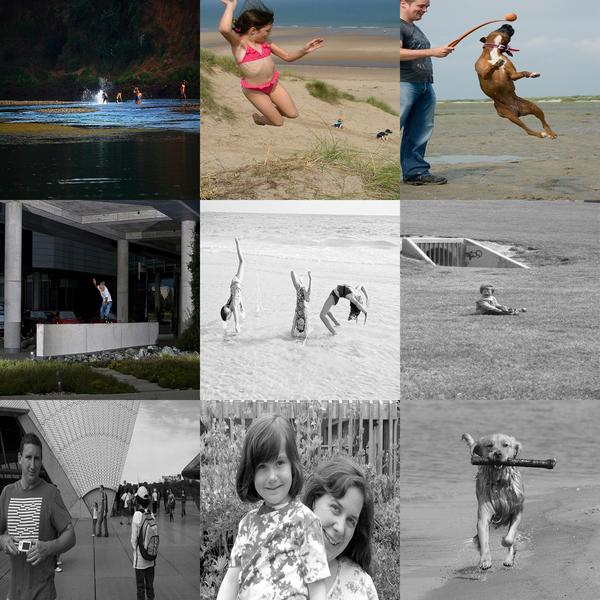
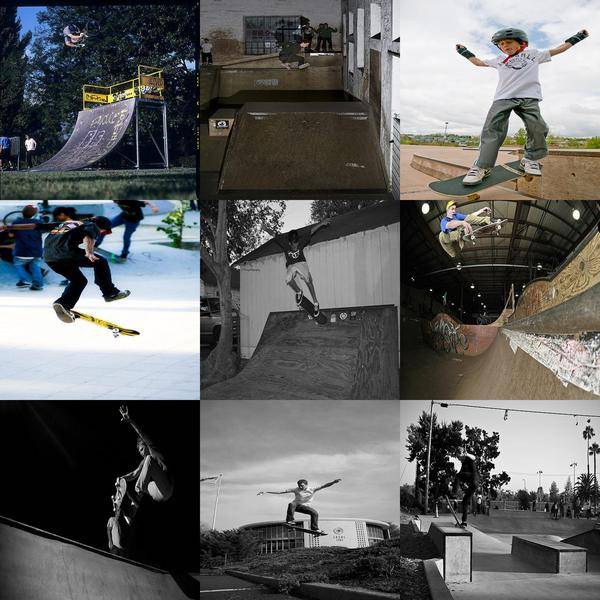
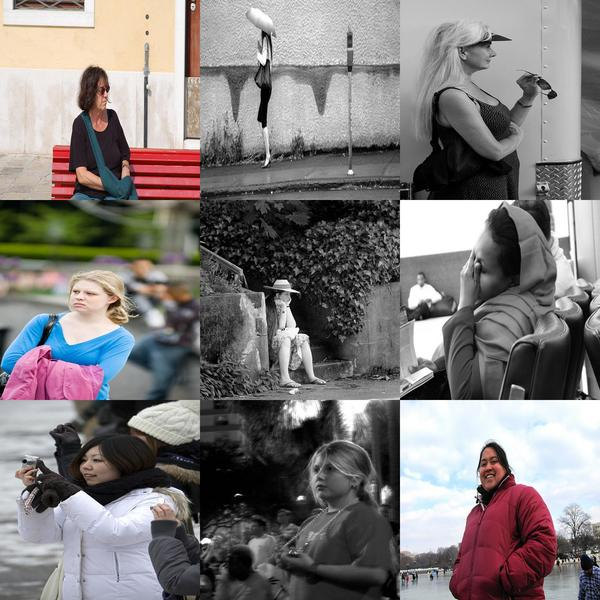
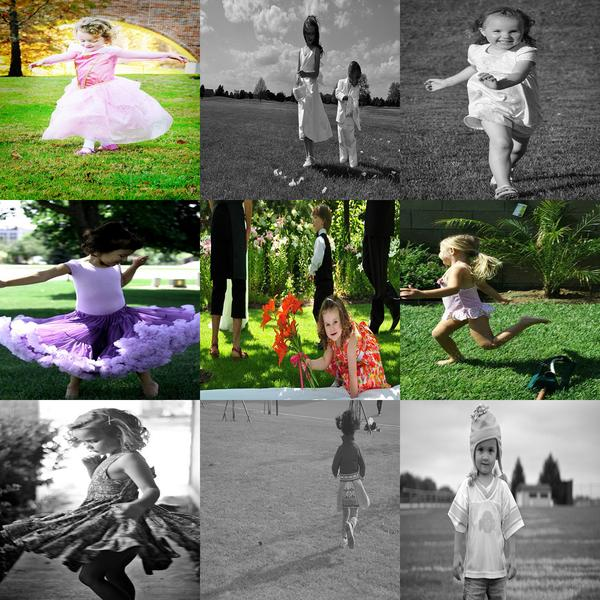

In [29]:
import base64
from io import BytesIO
from IPython.display import HTML
from PIL import Image

def get_thumbnail(im_path):
    image = Image.open(im_path)
    image.thumbnail((100, 100))  # Resize for display efficiency
    return image

def image_base64(im):
    if isinstance(im, str):
        im = get_thumbnail(im)
    with BytesIO() as buffer:
        im.save(buffer, 'jpeg')
        return base64.b64encode(buffer.getvalue()).decode()


def image_formatter(im):
    return f'<img src="data:image/jpeg;base64,{image_base64(im)}">'

# Extract dataframe
df = topic_model.get_topic_info().drop(["Representative_Docs", "Name"], axis=1)

df_sample = df.head(4)
# Visualize the images
HTML(df_sample.to_html(formatters={'Visual_Aspect': image_formatter}, escape=False))


## Images Only

Traditional topic modeling techniques can only be run on textual data, as is shown in the example above. However, there are plenty of cases where textual data is not available but images are. BERTopic allows topic modeling to be performed using only images as your input data.

To run BERTopic on images only, we first need to embed our images and then define a model that convert images to text. To do so, we are going to need some images. We will take the same images as the above but instead save them locally and pass the paths to the images instead. As mentioned before, this will make sure that we do not hold too many images in memory whilst only a small subset is needed:





In [30]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import util

# Flickr 8k images
img_folder = 'photos/'
caps_folder = 'captions/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)

    if not os.path.exists('Flickr8k_Dataset.zip'):   #Download dataset if does not exist
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset.zip')
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text.zip')

    for folder, file in [(img_folder, 'Flickr8k_Dataset.zip'), (caps_folder, 'Flickr8k_text.zip')]:
        with zipfile.ZipFile(file, 'r') as zf:
            for member in tqdm(zf.infolist(), desc='Extracting'):
                zf.extract(member, folder)
images = list(glob.glob('photos/Flicker8k_Dataset/*.jpg'))


  0%|          | 0.00/1.12G [00:00<?, ?B/s]

KeyboardInterrupt: 

Next, we can run our pipeline:

In [ ]:
from bertopic.representation import KeyBERTInspired, VisualRepresentation
from bertopic.backend import MultiModalBackend

# Image embedding model
embedding_model = MultiModalBackend('clip-ViT-B-32', batch_size=32)

# Image to text representation model
representation_model = {
    "Visual_Aspect": VisualRepresentation(image_to_text_model="nlpconnect/vit-gpt2-image-captioning")
}


Using these models, we can run our pipeline:

In [ ]:
from bertopic import BERTopic

# Train our model with images only
topic_model = BERTopic(embedding_model=embedding_model, representation_model=representation_model, min_topic_size=30)
topics, probs = topic_model.fit_transform(documents=None, images=images)


We can now access our image representations for each topic with topic_model.topic_aspects_["Visual_Aspect"]. If you want an overview of the topic images together with their textual representations in jupyter, you can run the following:

In [ ]:
import base64
from io import BytesIO
from IPython.display import HTML

def image_base64(im):
    if isinstance(im, str):
        im = get_thumbnail(im)
    with BytesIO() as buffer:
        im.save(buffer, 'jpeg')
        return base64.b64encode(buffer.getvalue()).decode()


def image_formatter(im):
    return f'<img src="data:image/jpeg;base64,{image_base64(im)}">'

# Extract dataframe
df = topic_model.get_topic_info().drop("Representative_Docs", 1).drop("Name", 1)

# Visualize the images
HTML(df.to_html(formatters={'Visual_Aspect': image_formatter}, escape=False))
